## 1. Load Dataset and Prepare Features

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler


In [2]:
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

if file_name.lower().endswith((".xlsx", ".xls")):
    df = pd.read_excel(file_name)
else:
    df = pd.read_csv(file_name, encoding_errors="ignore")

print("Original dataset shape:", df.shape)
display(df.head())

df_model = df.copy()

# Extract simple time features from the sale date.
if "date" in df_model.columns:
    df_model["date"] = pd.to_datetime(df_model["date"], errors="coerce")
    df_model["year"] = df_model["date"].dt.year
    df_model["month"] = df_model["date"].dt.month

# Remove columns that should not directly enter the model.
drop_cols = [col for col in ["id", "date"] if col in df_model.columns]
df_model = df_model.drop(columns=drop_cols)

# Basic cleaning.
df_model = df_model.dropna()
df_model = df_model[df_model["price"] > 0]

# Feature engineering used consistently across the three models.
if "yr_built" in df_model.columns:
    df_model["age"] = 2014 - df_model["yr_built"]

if "yr_renovated" in df_model.columns:
    df_model["is_renovated"] = (df_model["yr_renovated"] > 0).astype(int)

if {"bedrooms", "bathrooms"}.issubset(df_model.columns):
    df_model["total_rooms"] = df_model["bedrooms"] + df_model["bathrooms"]

if {"sqft_living", "sqft_lot"}.issubset(df_model.columns):
    df_model["living_to_lot_ratio"] = df_model["sqft_living"] / df_model["sqft_lot"].replace(0, np.nan)

if {"sqft_living", "floors"}.issubset(df_model.columns):
    df_model["sqft_per_floor"] = df_model["sqft_living"] / df_model["floors"].replace(0, np.nan)

# price_per_sqft is used for within-zipcode explanation only.
# It is not used as a training feature because it directly uses the target variable price.
if "sqft_living" in df_model.columns:
    df_model["price_per_sqft"] = df_model["price"] / df_model["sqft_living"].replace(0, np.nan)

# Remove rows generated with invalid engineered ratios.
df_model = df_model.replace([np.inf, -np.inf], np.nan).dropna()

print("Dataset shape after preprocessing:", df_model.shape)
display(df_model.head())


Saving MAI_GP_kc_house_data.xlsx to MAI_GP_kc_house_data.xlsx
Original dataset shape: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


Dataset shape after preprocessing: (21613, 27)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month,age,is_renovated,total_rooms,living_to_lot_ratio,sqft_per_floor,price_per_sqft
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,2014,10,59,0,4.00,0.208850,1180.0,188.050847
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014,12,63,1,5.25,0.354874,1285.0,209.338521
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062,2015,2,81,0,3.00,0.077000,770.0,233.766234
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,2014,12,49,0,7.00,0.392000,1960.0,308.163265
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,2015,2,27,0,5.00,0.207921,1680.0,303.571429


In [3]:
target_col = "price"

selected_features = [
    # house structure
    "bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors",
    "condition", "grade", "sqft_above", "sqft_basement",
    "yr_built", "yr_renovated",

    # engineered housing features
    "age", "is_renovated", "total_rooms",
    "living_to_lot_ratio", "sqft_per_floor",

    # location-related features
    "zipcode", "lat", "long", "waterfront", "view",
    "sqft_living15", "sqft_lot15",

    # time features
    "year", "month"
]

selected_features = [col for col in selected_features if col in df_model.columns]

X_raw = df_model[selected_features].copy()
y = df_model[target_col].copy()

# zipcode is a location category, not an ordinary continuous number.
# One-hot encoding avoids treating zipcode values as numerical rankings.
if "zipcode" in X_raw.columns:
    X_raw["zipcode"] = X_raw["zipcode"].astype(str)
    X = pd.get_dummies(X_raw, columns=["zipcode"], drop_first=True)
else:
    X = X_raw.copy()

X = X.astype(float)

print("Number of original selected features:", len(selected_features))
print("Number of final model features after zipcode one-hot encoding:", X.shape[1])
if "zipcode" in df_model.columns:
    print("Number of unique zipcodes:", df_model["zipcode"].nunique())
print("X shape:", X.shape)
print("y shape:", y.shape)


Number of original selected features: 25
Number of final model features after zipcode one-hot encoding: 93
Number of unique zipcodes: 70
X shape: (21613, 93)
y shape: (21613,)


## 2. Train Model and Evaluate Overall Performance

In [4]:
y_log = np.log1p(y)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_log, test_size=0.4, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


Train shape: (12967, 93)
Validation shape: (4323, 93)
Test shape: (4323, 93)


In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


In [6]:
def evaluate_regression(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return r2, mae, rmse, mape

model_name = "Linear Regression"

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_val_pred = model.predict(X_val_scaled)
y_test_pred = model.predict(X_test_scaled)

val_metrics = evaluate_regression(y_val, y_val_pred)
test_metrics = evaluate_regression(y_test, y_test_pred)

overall_results = pd.DataFrame({
    "Dataset": ["Validation", "Test"],
    "R2": [val_metrics[0], test_metrics[0]],
    "MAE": [val_metrics[1], test_metrics[1]],
    "RMSE": [val_metrics[2], test_metrics[2]],
    "MAPE (%)": [val_metrics[3], test_metrics[3]]
})

display(overall_results)


,Dataset,R2,MAE,RMSE,MAPE (%)
0,Validation,0.593148,78446.164099,230779.749743,13.866626
1,Test,0.837969,76994.941610,164998.734308,13.547231


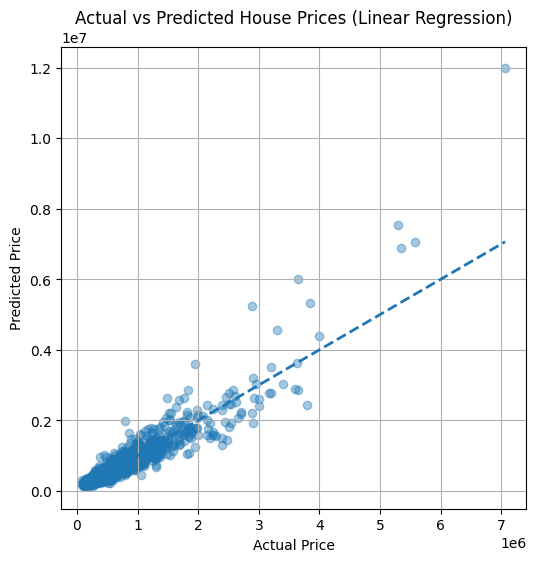

In [7]:
y_test_true = np.expm1(y_test)
y_test_pred_actual = np.expm1(y_test_pred)

plt.figure(figsize=(6, 6))
plt.scatter(y_test_true, y_test_pred_actual, alpha=0.4)
plt.plot(
    [y_test_true.min(), y_test_true.max()],
    [y_test_true.min(), y_test_true.max()],
    "--",
    linewidth=2
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices (Linear Regression)")
plt.grid(True)
plt.show()


,feature,coefficient,absolute_coefficient
10,yr_renovated,1.461054,1.461054
12,is_renovated,-1.444068,1.444068
26,zipcode_98004,0.115438,0.115438
6,grade,0.106559,0.106559
72,zipcode_98115,0.106038,0.106038
65,zipcode_98103,0.104430,0.104430
71,zipcode_98112,0.101469,0.101469
74,zipcode_98117,0.096364,0.096364
44,zipcode_98033,0.085831,0.085831
48,zipcode_98040,0.082519,0.082519


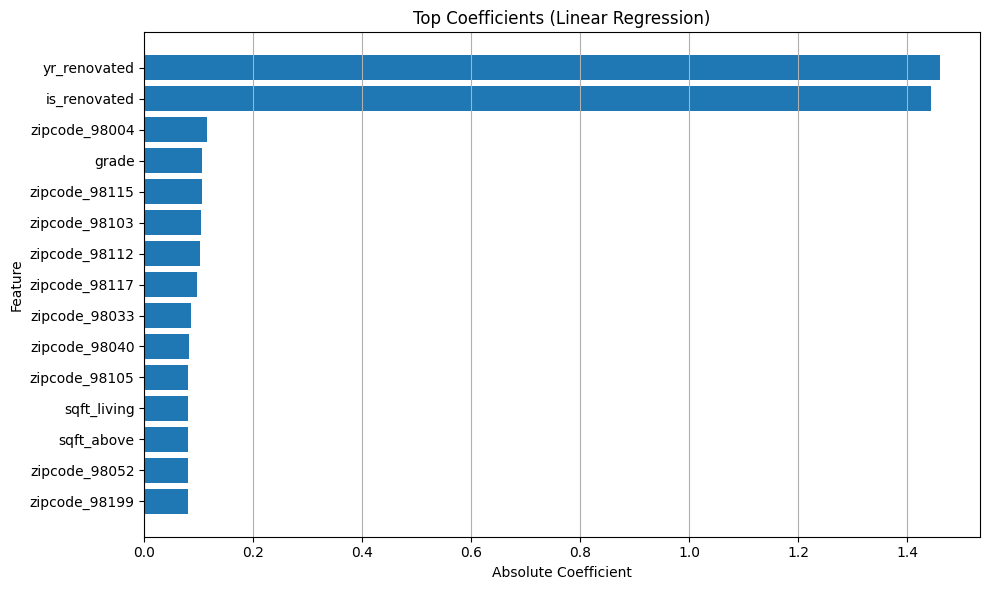

In [8]:
coefficient_importance = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_,
    "absolute_coefficient": np.abs(model.coef_)
}).sort_values("absolute_coefficient", ascending=False)

display(coefficient_importance.head(20))

plt.figure(figsize=(10, 6))
plt.barh(coefficient_importance.head(15)["feature"], coefficient_importance.head(15)["absolute_coefficient"])
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.title("Top Coefficients (Linear Regression)")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.tight_layout()
plt.show()


## 3. Zipcode-Level Model Stability Analysis

In [9]:
location_result = pd.DataFrame({
    "actual_price": y_test_true,
    "predicted_price": y_test_pred_actual
}, index=X_test.index)

location_result["zipcode"] = df_model.loc[X_test.index, "zipcode"].astype(str).values
location_result["absolute_error"] = np.abs(location_result["actual_price"] - location_result["predicted_price"])
location_result["squared_error"] = (location_result["actual_price"] - location_result["predicted_price"]) ** 2
location_result["percentage_error"] = (location_result["absolute_error"] / location_result["actual_price"]) * 100
location_result["prediction_bias"] = location_result["predicted_price"] - location_result["actual_price"]

zipcode_performance = location_result.groupby("zipcode").agg(
    sample_count=("actual_price", "count"),
    mean_actual_price=("actual_price", "mean"),
    mean_predicted_price=("predicted_price", "mean"),
    MAE=("absolute_error", "mean"),
    RMSE=("squared_error", lambda x: np.sqrt(np.mean(x))),
    MAPE=("percentage_error", "mean"),
    mean_bias=("prediction_bias", "mean")
).reset_index()

min_samples = 20
zipcode_performance_stable = zipcode_performance[
    zipcode_performance["sample_count"] >= min_samples
].copy()

zipcode_performance_stable = zipcode_performance_stable.sort_values("MAPE", ascending=False)

print("Number of zipcodes in full dataset:", df_model["zipcode"].nunique())
print("Number of zipcodes in test set:", zipcode_performance.shape[0])
print(f"Number of zipcodes with at least {min_samples} test samples:", zipcode_performance_stable.shape[0])

display(zipcode_performance_stable.head(15))


Number of zipcodes in full dataset: 70
Number of zipcodes in test set: 70
Number of zipcodes with at least 20 test samples: 66


,zipcode,sample_count,mean_actual_price,mean_predicted_price,MAE,RMSE,MAPE,mean_bias
60,98146,53,3.260339e+05,3.166656e+05,76883.202521,103310.181556,28.028120,-9368.283341
46,98108,33,3.344406e+05,3.431915e+05,54271.651023,69011.070730,22.644980,8750.913254
52,98118,106,4.458410e+05,4.085097e+05,95518.390341,144706.018273,21.836228,-37331.332619
63,98166,57,5.073702e+05,5.532061e+05,107431.112325,221044.123312,21.473736,45835.895485
35,98070,22,4.918025e+05,4.496539e+05,105072.164245,139576.519597,19.054702,-42148.515296
42,98103,125,5.847349e+05,5.507516e+05,105497.801190,136390.393594,18.540540,-33983.259026
44,98106,61,3.117914e+05,2.994993e+05,47531.925761,64727.466452,17.152082,-12292.129115
3,98004,77,1.506270e+06,1.559348e+06,297204.896533,660724.650088,17.020325,53078.642969
53,98119,40,9.190344e+05,8.708502e+05,140973.876226,198811.675936,16.591104,-48184.150342
64,98168,54,2.458565e+05,2.480578e+05,37318.651049,47328.117448,16.558769,2201.291093


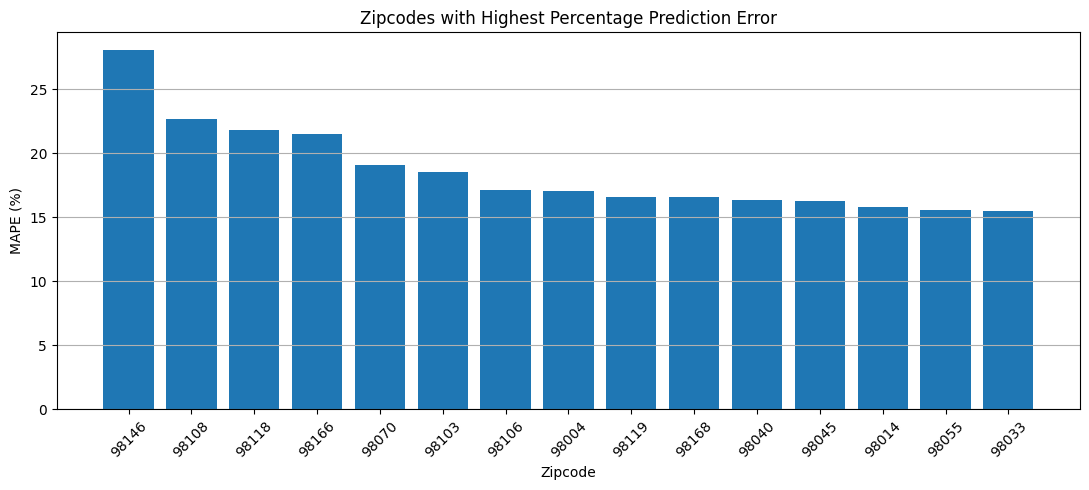

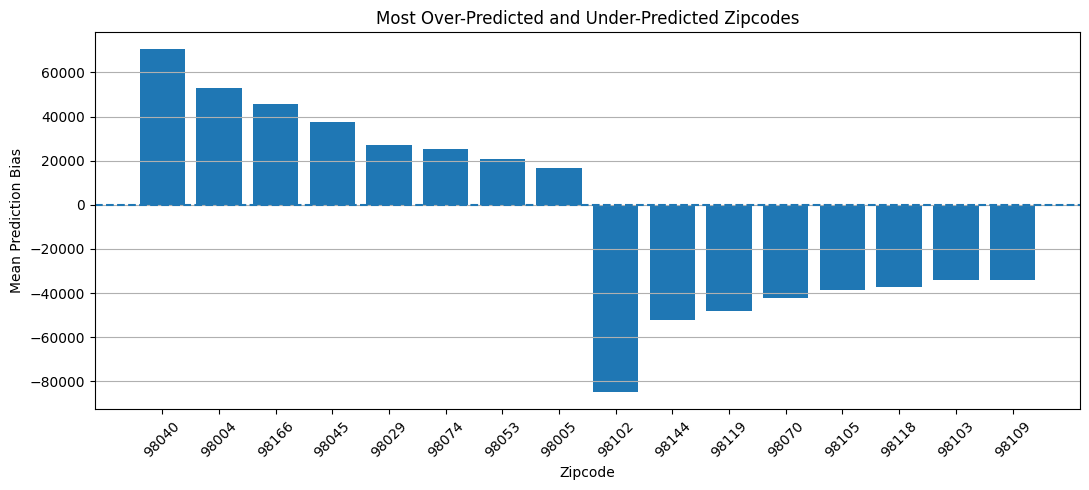

In [10]:
top_mape_zipcodes = zipcode_performance_stable.sort_values("MAPE", ascending=False).head(15)

plt.figure(figsize=(11, 5))
plt.bar(top_mape_zipcodes["zipcode"], top_mape_zipcodes["MAPE"])
plt.xlabel("Zipcode")
plt.ylabel("MAPE (%)")
plt.title("Zipcodes with Highest Percentage Prediction Error")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

most_over = zipcode_performance_stable.sort_values("mean_bias", ascending=False).head(8)
most_under = zipcode_performance_stable.sort_values("mean_bias", ascending=True).head(8)
bias_plot_data = pd.concat([most_over, most_under])

plt.figure(figsize=(11, 5))
plt.bar(bias_plot_data["zipcode"], bias_plot_data["mean_bias"])
plt.axhline(0, linestyle="--")
plt.xlabel("Zipcode")
plt.ylabel("Mean Prediction Bias")
plt.title("Most Over-Predicted and Under-Predicted Zipcodes")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()


## 4. Within-Zipcode Price Difference Analysis

In [11]:
zipcode_price_summary = df_model.copy()
zipcode_price_summary["zipcode"] = zipcode_price_summary["zipcode"].astype(str)

zipcode_price_summary = zipcode_price_summary.groupby("zipcode").agg(
    sample_count=("price", "count"),
    mean_price=("price", "mean"),
    median_price=("price", "median"),
    min_price=("price", "min"),
    max_price=("price", "max"),
    price_std=("price", "std"),
    mean_price_per_sqft=("price_per_sqft", "mean")
).reset_index()

zipcode_price_summary["price_range"] = (
    zipcode_price_summary["max_price"] - zipcode_price_summary["min_price"]
)

zipcode_price_summary = zipcode_price_summary.sort_values("price_range", ascending=False)

display(zipcode_price_summary.head(15))


,zipcode,sample_count,mean_price,median_price,min_price,max_price,price_std,mean_price_per_sqft,price_range
41,98102,105,9.012583e+05,720000.0,330000.0,7700000.0,7.866621e+05,423.172498,7370000.0
3,98004,317,1.355927e+06,1150000.0,425000.0,7062500.0,7.458201e+05,475.435611,6637500.0
24,98039,50,2.160607e+06,1892500.0,787500.0,6885000.0,1.166477e+06,568.083350,6097500.0
21,98033,432,8.037195e+05,678350.0,130000.0,5110800.0,4.625210e+05,343.162454,4980800.0
25,98040,282,1.194230e+06,993750.0,500000.0,5300000.0,6.074935e+05,387.292524,4800000.0
62,98155,446,4.237257e+05,375000.0,153000.0,4500000.0,2.682093e+05,246.519033,4347000.0
5,98006,498,8.596848e+05,760184.5,247500.0,4208000.0,4.459116e+05,299.091476,3960500.0
65,98177,255,6.761854e+05,554000.0,245560.0,3800000.0,4.358499e+05,292.918745,3554440.0
59,98144,343,5.945477e+05,450000.0,181000.0,3600000.0,4.005904e+05,312.241854,3419000.0
7,98008,283,6.455074e+05,545000.0,250000.0,3567000.0,4.215900e+05,301.717731,3317000.0


In [12]:
candidate_factors = [
    "sqft_living", "sqft_lot", "bedrooms", "bathrooms", "floors",
    "grade", "condition", "waterfront", "view", "age", "is_renovated",
    "sqft_living15", "sqft_lot15", "price_per_sqft"
]

candidate_factors = [col for col in candidate_factors if col in df_model.columns]

within_zipcode_results = []

for zipcode, group in df_model.groupby("zipcode"):
    if len(group) < 30:
        continue

    correlations = {}

    for factor in candidate_factors:
        if group[factor].nunique() > 1:
            corr = group[[factor, "price"]].corr(numeric_only=True).iloc[0, 1]
            if pd.notna(corr):
                correlations[factor] = corr

    if not correlations:
        continue

    strongest_factor = max(correlations, key=lambda factor: abs(correlations[factor]))

    within_zipcode_results.append({
        "zipcode": str(zipcode),
        "sample_count": len(group),
        "mean_price": group["price"].mean(),
        "median_price": group["price"].median(),
        "price_range": group["price"].max() - group["price"].min(),
        "price_std": group["price"].std(),
        "strongest_factor": strongest_factor,
        "strongest_correlation": correlations[strongest_factor]
    })

within_zipcode_analysis = pd.DataFrame(within_zipcode_results)
within_zipcode_analysis = within_zipcode_analysis.sort_values("price_range", ascending=False)

display(within_zipcode_analysis.head(15))


,zipcode,sample_count,mean_price,median_price,price_range,price_std,strongest_factor,strongest_correlation
41,98102,105,9.012583e+05,720000.0,7370000.0,7.866621e+05,sqft_living,0.910310
3,98004,317,1.355927e+06,1150000.0,6637500.0,7.458201e+05,sqft_living,0.856166
24,98039,50,2.160607e+06,1892500.0,6097500.0,1.166477e+06,sqft_living,0.940887
21,98033,432,8.037195e+05,678350.0,4980800.0,4.625210e+05,sqft_living,0.820998
25,98040,282,1.194230e+06,993750.0,4800000.0,6.074935e+05,sqft_living,0.788251
62,98155,446,4.237257e+05,375000.0,4347000.0,2.682093e+05,waterfront,0.756437
5,98006,498,8.596848e+05,760184.5,3960500.0,4.459116e+05,sqft_living,0.801393
65,98177,255,6.761854e+05,554000.0,3554440.0,4.358499e+05,grade,0.813959
59,98144,343,5.945477e+05,450000.0,3419000.0,4.005904e+05,sqft_living,0.825459
7,98008,283,6.455074e+05,545000.0,3317000.0,4.215900e+05,waterfront,0.829500


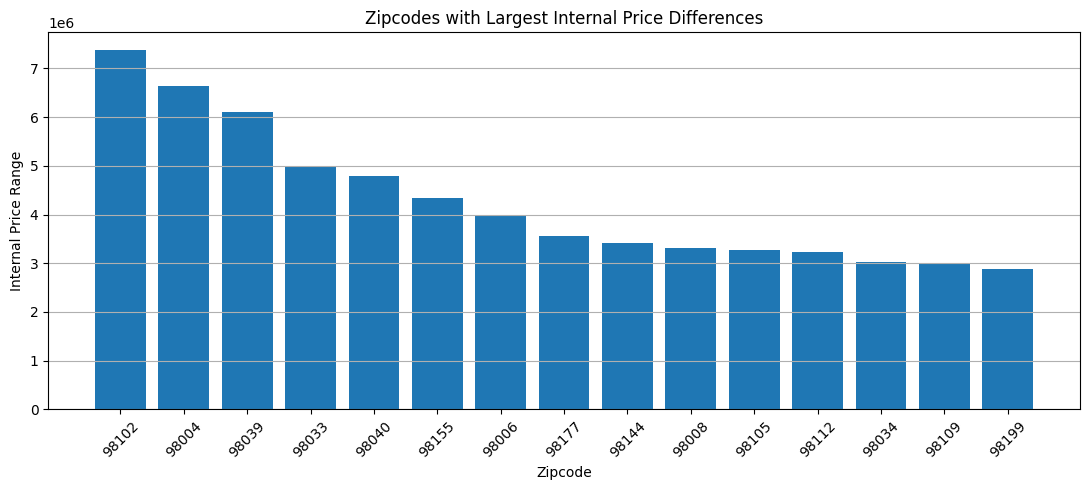

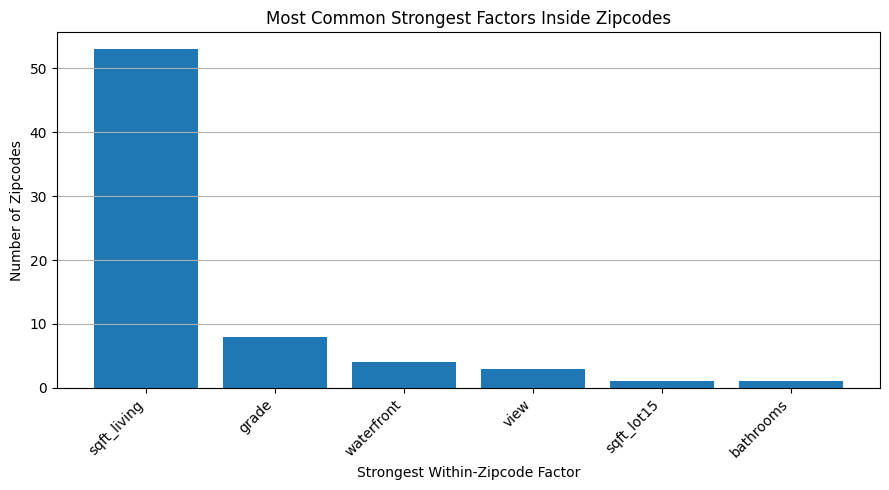

In [13]:
top_internal_range = within_zipcode_analysis.head(15)

plt.figure(figsize=(11, 5))
plt.bar(top_internal_range["zipcode"], top_internal_range["price_range"])
plt.xlabel("Zipcode")
plt.ylabel("Internal Price Range")
plt.title("Zipcodes with Largest Internal Price Differences")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

factor_counts = within_zipcode_analysis["strongest_factor"].value_counts()

plt.figure(figsize=(9, 5))
plt.bar(factor_counts.index, factor_counts.values)
plt.xlabel("Strongest Within-Zipcode Factor")
plt.ylabel("Number of Zipcodes")
plt.title("Most Common Strongest Factors Inside Zipcodes")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


## 5. Summary for Report Writing

In [15]:
overall_test_row = overall_results[overall_results["Dataset"] == "Test"].iloc[0]
highest_mape_row = zipcode_performance_stable.sort_values("MAPE", ascending=False).iloc[0]
lowest_mape_row = zipcode_performance_stable.sort_values("MAPE", ascending=True).iloc[0]
largest_price_range_row = zipcode_price_summary.iloc[0]
top_within_factor_row = within_zipcode_analysis.iloc[0]

mape_mean = zipcode_performance_stable["MAPE"].mean()
mape_std = zipcode_performance_stable["MAPE"].std()

print("Summary for report writing")
print("=" * 40)
print(f"Model: {model_name}")
print(f"Test R2: {overall_test_row['R2']:.4f}")
print(f"Test MAE: {overall_test_row['MAE']:,.2f}")
print(f"Test RMSE: {overall_test_row['RMSE']:,.2f}")
print(f"Test MAPE: {overall_test_row['MAPE (%)']:.2f}%")

print(f"\nAverage zipcode-level MAPE among stable zipcodes: {mape_mean:.2f}%")
print(f"Variation of zipcode-level MAPE: {mape_std:.2f} percentage points")
print(f"Highest MAPE zipcode: {highest_mape_row['zipcode']} with MAPE {highest_mape_row['MAPE']:.2f}%")
print(f"Lowest MAPE zipcode: {lowest_mape_row['zipcode']} with MAPE {lowest_mape_row['MAPE']:.2f}%")

print(f"\nZipcode with largest internal price range: {largest_price_range_row['zipcode']}")
print(f"Price range in this zipcode: {largest_price_range_row['price_range']:,.2f}")

print(f"\nAmong zipcodes with enough records, the zipcode with the largest internal price range is {top_within_factor_row['zipcode']}.")
print(f"The strongest correlated factor inside this zipcode is {top_within_factor_row['strongest_factor']}, with correlation {top_within_factor_row['strongest_correlation']:.3f}.")


Summary for report writing
Model: Linear Regression
Test R2: 0.8380
Test MAE: 76,994.94
Test RMSE: 164,998.73
Test MAPE: 13.55%

Average zipcode-level MAPE among stable zipcodes: 13.59%
Variation of zipcode-level MAPE: 3.52 percentage points
Highest MAPE zipcode: 98146 with MAPE 28.03%
Lowest MAPE zipcode: 98031 with MAPE 7.55%

Zipcode with largest internal price range: 98102
Price range in this zipcode: 7,370,000.00

Among zipcodes with enough records, the zipcode with the largest internal price range is 98102.
The strongest correlated factor inside this zipcode is sqft_living, with correlation 0.910.
